# Week5 - Logistic Regression Assignment

- Run the below cells.
- Complete all of the numbered questions. You may call any packages that we've used in class.  

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv(r'https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/log_reg/employee-turnover-balanced.csv')
df.head()

,left_company,age,frequency_of_travel,department,commuting_distance,education,satisfaction_with_environment,gender,seniority_level,position,satisfaction_with_job,married_or_single,last_raise_pct,last_performance_rating,total_years_working,years_at_company,years_in_current_job,years_since_last_promotion,years_with_current_supervisor
0,No,37,Travel_Rarely,Sales,16,4,4,Male,2,Sales Executive,3,Divorced,19,3,9,1,0,0,0
1,No,39,Travel_Rarely,Research & Development,3,2,3,Male,2,Laboratory Technician,3,Divorced,15,3,11,10,8,0,7
2,No,52,Travel_Frequently,Research & Development,25,4,3,Female,4,Manufacturing Director,4,Married,22,4,31,9,8,0,0
3,No,50,Non-Travel,Sales,1,3,4,Female,2,Sales Executive,3,Married,12,3,19,18,7,0,13
4,No,44,Travel_Rarely,Research & Development,4,3,4,Male,2,Healthcare Representative,2,Single,12,3,10,5,2,2,3


## Data Definitions
- `left_company`: Whether individual left the company or not. This is the target variable.  
- `age`: Age of individual.
- `frequency_of_travel`: How often person travels for work.  
- `department`: Department person works(worked).  
- `commuting_distance`: Distance person lives from office.  
- `education`: Highest education category.  
- `satisfaction_with_environment`: Satisfaction of environment, on lickert scale.  
- `gender`: Gender of individual.  
- `seniority_level`: Seniority level of individual.  
- `position`: Last position held at the company.  
- `satisfaction_with_job`: Satisfaction of their job, on lickert scale.  
- `married_or_single`: Marital status of person.  
- `last_raise_pct`: Percent increase their last raise represented.  
- `last_performance_rating`: Most recent annual performance rating, on lickert scale.  
- `total_years_working`: Number of years the individual has spent working in their career.  
- `years_at_company`: Number of years the individual has been at the company, regardless of position.  
- `years_in_current_job`: Number of years the individual has been in their current position.  
- `years_since_last_promotion`: Years since the person had their last promotion.  
- `years_with_current_supervisor`: Years the person has had their current supervisor.

# Question 1
- What is the distribution of the target (`left_company`)?  
- Do you have any concerns on class imbalances?

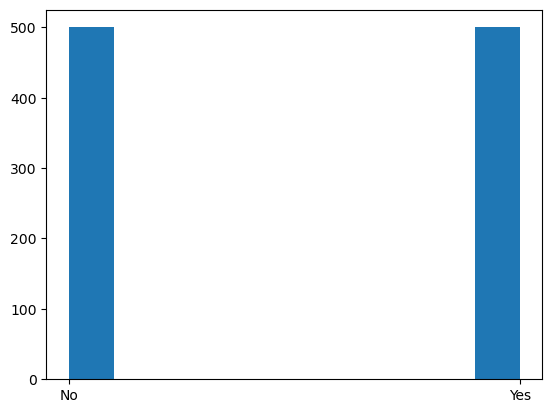

In [69]:
plt.hist(df['left_company'])
plt.show()

In [70]:
Target_dist = df['left_company'].value_counts()
print(Target_dist)

No     500
Yes    500
Name: left_company, dtype: int64


- There is no class imbalance in the provided dataset.

# Question 2
- Create and print a list of the variables that you would treat as numerical and another list for the variables that you would treat as categorical.  
- Explain your choices.

In [71]:
num_vars = ['age', 'commuting_distance', 'education', 'satisfaction_with_environment', 'seniority_level', 'satisfaction_with_job', 'last_raise_pct', 'last_performance_rating', 'total_years_working', 'years_at_company', 'years_in_current_job', 'years_since_last_promotion', 'years_with_current_supervisor']
cat_vars = ['frequency_of_travel', 'department', 'gender','position','married_or_single']

print("Numerical Variables:\n", num_vars)
print("\nCategorical Variables:\n", cat_vars)


Numerical Variables:
 ['age', 'commuting_distance', 'education', 'satisfaction_with_environment', 'seniority_level', 'satisfaction_with_job', 'last_raise_pct', 'last_performance_rating', 'total_years_working', 'years_at_company', 'years_in_current_job', 'years_since_last_promotion', 'years_with_current_supervisor']

Categorical Variables:
 ['frequency_of_travel', 'department', 'gender', 'position', 'married_or_single']


- I categorized the all the numerical termed columns to the Numerical and all the other categorical columns like gender department are into the categorical columns.

# Question 3
- Determine if any numerical variables risk multicolinearity.  
- Remove those variables (if any) from your numerical_vars list.  
- Why did you or did not remove any?

In [72]:
# insert code here
num_vars = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_df = df[num_vars]
corr_matrix = num_df.corr()
correlated_vars = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) >0.7:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            correlated_vars.add(col_i)
            correlated_vars.add(col_j)
num_vars = [col for col in num_vars if col not in correlated_vars]
num_vars

['age',
 'commuting_distance',
 'education',
 'satisfaction_with_environment',
 'satisfaction_with_job',
 'years_since_last_promotion']

Insert comments here

# Question 4
- Split the data into training and test sets.  
- Use 20% of the data for test and a random state of 124.  

In [73]:
X = df.drop('left_company', axis=1)
y = df['left_company']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=124)

print('Training set shape:', X_train.shape, y_train.shape)
print('Test set shape:', X_test.shape, y_test.shape)

Training set shape: (800, 18) (800,)
Test set shape: (200, 18) (200,)


# Question 5
- Create a pipeline to process the numerical data.  
- Create a pipeline to process the categorical data.  

Verify each pipeline contains the columns you would expect using a fit_transform on the training data, i.e., print the shapes of the fit_transforms for each pipeline.

In [74]:
# insert code here
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [75]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [76]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_vars),
    ('cat', cat_transformer, cat_vars)
])

In [77]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'commuting_distance', 'education',
                                  'satisfaction_with_environment',
                                  'satisfaction_with_job',
                                  'years_since_last_promotion']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['frequency_of_travel', 'department', 'gender',
                                  'position', 'married_or_single'])])

In [78]:
X_train_processed = preprocessor.fit_transform(X_train)

In [79]:
print("Numerical features shape:", X_train_processed[:, :len(num_vars)].shape)
print("Categorical features shape:", X_train_processed[:, len(num_vars):].shape)

Numerical features shape: (800, 6)
Categorical features shape: (800, 20)


# Question 6
- Create a pipeline that combines the pre-processing and implements a logistic regression model.  
- Print the accuracy on the training set and the test set.
- Do you have any concerns of overfitting based on the differences between the two accuracy scores?

In [80]:
p = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', LogisticRegression())
])
p.fit(X_train, y_train)
y_train_pred = p.predict(X_train)
y_test_pred = p.predict(X_test)
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f"Accuracy on the training set: {accuracy_train:.4f}")
print(f"Accuracy on the test set: {accuracy_test:.4f}")

Accuracy on the training set: 0.7137
Accuracy on the test set: 0.6450


### Insert comments here

There might be some overfitting in your model according to the difference between the training accuracy (0.7137) and the test accuracy (0.6450). When the training accuracy is much greater than the test accuracy, the model is likely overfitting the training data, collecting noise or certain patterns that do not translate well to new data.





# Question 7
What would you recommend as potential next steps for continuing to develop and evaluate a model?

Insert comments here

Model Selection: Instead of restricting yourself to a single model, trying  out different models or techniques like decision trees, random forests, support vector machines (SVMs), to determine the one that works best for your specific data and problem.

To improve the collection of data links, try developing new features or changing existing ones. Consider attempting to combine several aspects or coming up with interaction words. Usually, this enhances the performance of the model.

To determine which model or methodology works best with your data, experimenting with a few alternative options. Support vector machines (SVMs), decision trees, random forests, and neural networks are a few of the frequently used methods for categorization challenges.

After selecting a model, experiment with fine-tuning its hyperparameters to assess whether you can improve its performance. Hyperparameters, such as the learning rate of a neural network or the maximum depth of a decision tree, are user-defined settings rather than parameters learned from the data.